<a href="https://colab.research.google.com/github/Sanika-tech123/Deep-Learning-Lab/blob/main/DL_5_Classifying_IMDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset Loaded Successfully
Training Data: 25000
Testing Data: 25000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7939 - loss: 0.5387 - val_accuracy: 0.8752 - val_loss: 0.3714
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9052 - loss: 0.2834 - val_accuracy: 0.8894 - val_loss: 0.2818
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9317 - loss: 0.1969 - val_accuracy: 0.8936 - val_loss: 0.2752
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9485 - loss: 0.1509 - val_accuracy: 0.8886 - val_loss: 0.2861
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9611 - loss: 0.1205 - val_accuracy: 0.8886 - val_loss: 0.3036
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8757 - loss: 0.3271

Test Loss: 0.3271353244781494
Test Accuracy: 0.8756800293922424


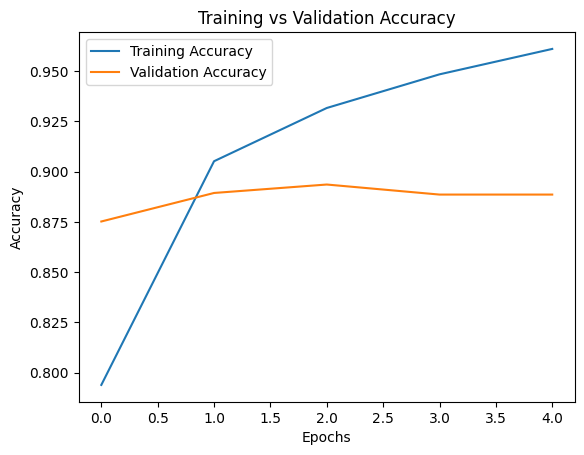

In [ ]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Load IMDB Dataset
# ---------------------------------------------------

# Keep only top 10000 most common words
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

print("Dataset Loaded Successfully")

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

# ---------------------------------------------------
# Convert Reviews into Vector Format
# ---------------------------------------------------

def vectorize(sequences, dimension=10000):

    results = tf.zeros((len(sequences), dimension))

    results = results.numpy()

    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.

    return results

X_train = vectorize(X_train)
X_test = vectorize(X_test)

# ---------------------------------------------------
# Build Deep Neural Network
# ---------------------------------------------------

model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(10000,)))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

# ---------------------------------------------------
# Compile Model
# ---------------------------------------------------

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ---------------------------------------------------
# Train Model
# ---------------------------------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=512,
    validation_split=0.2
)

# ---------------------------------------------------
# Evaluate Model
# ---------------------------------------------------

results = model.evaluate(X_test, y_test)

print("\nTest Loss:", results[0])
print("Test Accuracy:", results[1])

# ---------------------------------------------------
# Graph
# ---------------------------------------------------

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.show()